#  Банковские карты клиентов

**Набор данных о банковских картах** — часть исследовательского проекта по анализу индийских финансовых данных и выявлению мошеннических операций.

Цель данного ноутбука — провести **разведочный анализ данных (EDA)** набора `Cards_Data.csv`: изучить структуру данных, распределения признаков и связи между ними.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

## Содержание

1. [Первичный обзор данных](#первичный-обзор-данных)
2. [Исследование по платёжной системе](#исследование-карт-по-платёжной-системе)
3. [Исследование типов карт](#исследование-распределения-типов-карт)
4. [Карты на одного пользователя](#наличие-нескольких-карт-у-одного-пользователя)
5. [Кредитный лимит и тип карты](#исследование-связи-между-credit_limit-и-card_type)
6. [Кредитный лимит и платёжная система](#исследование-связи-между-credit_limit-и-card_network)
7. [Статус карты](#карты-по-статусу)
8. [Бесконтактные карты](#карты-по-поддержке-бесконтактной-оплаты)
9. [Способ эмиссии карт](#карты-по-способу-эмиссии)
10. [Срок действия карт](#срок-действия-карт)
11. [Общие выводы](#общие-выводы)

## Первичный обзор данных

In [2]:
df = pd.read_csv("data/Cards_Data.csv")
pd.set_option("display.float_format", "{:.2f}".format)

print(f"Количество строк {df.shape[0]}, количество столбцов {df.shape[1]}")
print("\n-----------------------")
print("Информация о типах данных")
df.info()
print("\n-----------------------")
print("Выборка первых записей")
print(df.head())
print("\n-----------------------")
print("Количество дубликатов")
print(df.duplicated().sum())
print("\n-----------------------")
print("Количество пропущенных значений")
print(df.isna().sum())
print("\n-----------------------")
print("распределение числовых данных")
print(df.describe())

Количество строк 32457, количество столбцов 10

-----------------------
Информация о типах данных
<class 'pandas.DataFrame'>
RangeIndex: 32457 entries, 0 to 32456
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Card_ID       32457 non-null  str  
 1   Customer_ID   32457 non-null  str  
 2   Card_Type     32457 non-null  str  
 3   Card_Network  32457 non-null  str  
 4   Credit_Limit  32457 non-null  int64
 5   Card_Status   32457 non-null  str  
 6   Contactless   32457 non-null  str  
 7   Card_Mode     32457 non-null  str  
 8   Issue_Date    32457 non-null  str  
 9   Expiry_Date   32457 non-null  str  
dtypes: int64(1), str(9)
memory usage: 2.5 MB

-----------------------
Выборка первых записей
      Card_ID Customer_ID Card_Type Card_Network  Credit_Limit Card_Status  \
0  CARD500001  CUST100001      Gold        RuPay        587317      Active   
1  CARD500002  CUST100002    Silver         Visa        150720

## Итоги EDA 

В датасете **32 457 записей** и **10 признаков**.

**Пропущенные значения и полные дубликаты отсутствуют**.

Датасет содержит один числовой признак — **Credit_Limit**, два идентификатора — **Card_ID** и **Customer_ID**, а остальные признаки являются категориальными или датами. **Card_ID** является, скорее всего, техническим параметром, однако **Customer_ID** требует дополнительного анализа на предмет принадлежности нескольких карт одному пользователю с последующей визуализацией распределения.

**Credit_Limit** имеет диапазон от **50 002** до **1 499 927**, поэтому его распределение и возможные связи с категориальными признаками требуют дальнейшего исследования.

**Планы на дальнейший анализ**

1. Исследовать распределение платежных систем. 
2. Исследовать распределение типов карт.
3. Исследовать наличие нескольких карт у одного пользователя 
4. Исследовать связь между **Credit_Limit** и **Card_Type**.
5. Исследовать связь между **Credit_Limit** и **Card_Network**.
6. Исследовать категориальные признаки **Card_Status**, **Contactless**, **Card_Mode**.
7. Исследовать даты выпуска и истечения срока действия карт.

## Исследование карт по платежной системе 

In [3]:
card_counts = df["Card_Network"].value_counts()
print(card_counts)

Card_Network
American Express    8276
RuPay               8141
Visa                8101
Mastercard          7939
Name: count, dtype: int64


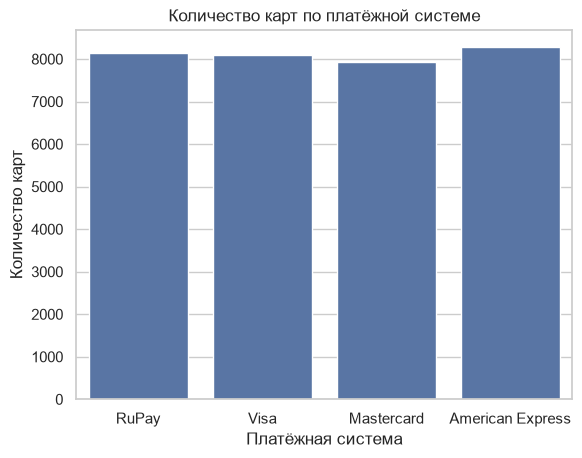

In [4]:
sns.countplot(
    data=df,
    x="Card_Network"
)

plt.title("Количество карт по платёжной системе")
plt.xlabel("Платёжная система")
plt.ylabel("Количество карт")

plt.show()

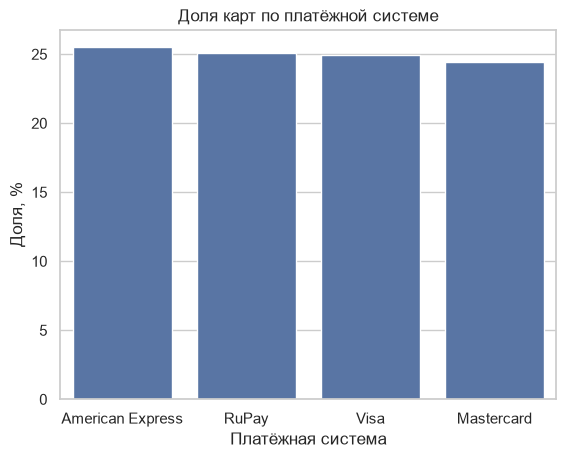

In [5]:
card_share = df['Card_Network'].value_counts(normalize=True) * 100

sns.barplot(
    x = card_share.index,
    y = card_share.values
)
plt.title("Доля карт по платёжной системе")
plt.xlabel("Платёжная система")
plt.ylabel("Доля, %")

plt.show()

## Вывод по разделу: 

распределение карт по платёжным системам является достаточно равномерным: ни одна из систем не имеет выраженного доминирования. Доля каждой платёжной системы составляет приблизительно 24–26% от общего количества карт.

Это указывает на отсутствие существенного дисбаланса между платёжными системами в представленной выборке. При этом количество карт не обязательно соответствует количеству пользователей, поскольку один пользователь потенциально может владеть несколькими картами.

Поэтому возникает дополнительная гипотеза: часть пользователей может использовать несколько карт различных платёжных систем для проведения финансовых операций. В дальнейшем данную гипотезу необходимо проверить путем анализа связи между идентификатором клиента и количеством принадлежащих ему карт, а также характера и частоты совершаемых им транзакций

## Исследование распределения типов карт

In [6]:
card_counts = df["Card_Type"].value_counts()
print(card_counts)

Card_Type
Gold        9973
Silver      9054
Classic     7348
Platinum    6082
Name: count, dtype: int64


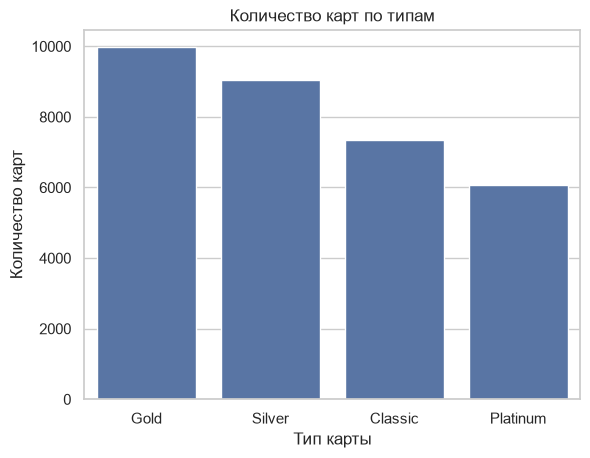

In [7]:
sns.countplot(
    data=df,
    x="Card_Type"
)

plt.title("Количество карт по типам")
plt.xlabel("Тип карты")
plt.ylabel("Количество карт")

plt.show()

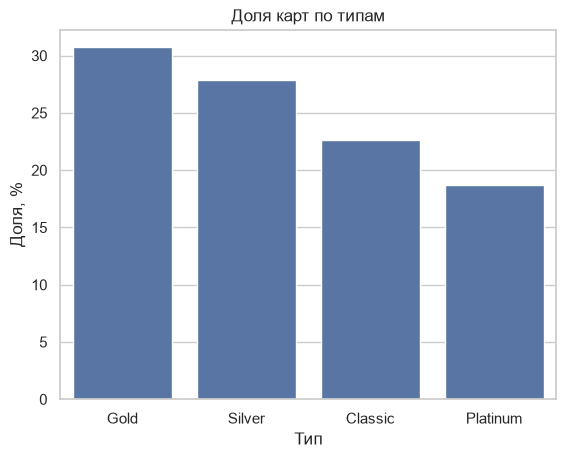

In [8]:
card_share = df['Card_Type'].value_counts(normalize=True) * 100

sns.barplot(
    x = card_share.index,
    y = card_share.values
)
plt.title("Доля карт по типам")
plt.xlabel("Тип")
plt.ylabel("Доля, %")

plt.show()

## Вывод по разделу: 

Наиболее распространённым типом карт является Gold, на который приходится около 31% всех карт в выборке. Второе место занимает Silver — около 28%. Таким образом, на эти два типа приходится более половины всех карт.

Далее следуют Classic с долей около 23% и Platinum — около 19%. Наблюдается разрыв в популярности типов карт: Gold и Silver представлены заметно чаще, чем Classic и Platinum.

Возникает гипотеза о возможной связи между типом карты и величиной кредитного лимита. Если карты Gold и Silver действительно характеризуются более подходящими для пользователей кредитными лимитами это может объяснять их более высокую представленность в выборке.

Для проверки данной гипотезы необходимо сопоставить Card_Type с Credit_Limit и проверить наличие связи между типом карты и величиной кредитного лимита. В частности, следует сравнить медиану, среднее значение и диапазон кредитных лимитов для Gold, Silver, Classic и Platinum

## Наличие несколько карт у одного пользователя 


In [9]:
print(f"Количество дубликатов Card_ID: {df['Card_ID'].duplicated().sum()}")

print(f"Количество уникальных пользователей {df['Customer_ID'].nunique()}")
print(f"Количество уникальных карт {df['Card_ID'].nunique()}")

Количество дубликатов Card_ID: 0
Количество уникальных пользователей 25000
Количество уникальных карт 32457


Поскольку карт больше, чем пользователей из этого следует вывод, что у одного пользователя может быть несколько карт. Сейчас необходимо у какого процента пользователей 2 и более карты. 

Уникальность Card_ID позволяет корректно определить количество карт, принадлежащих каждому пользователю, без риска повторного учёта одной карты.

In [10]:
cards_per_customer = df.groupby("Customer_ID")["Card_ID"].nunique().value_counts().sort_index()
print(cards_per_customer)

Card_ID
1    18796
2     4951
3     1253
Name: count, dtype: int64


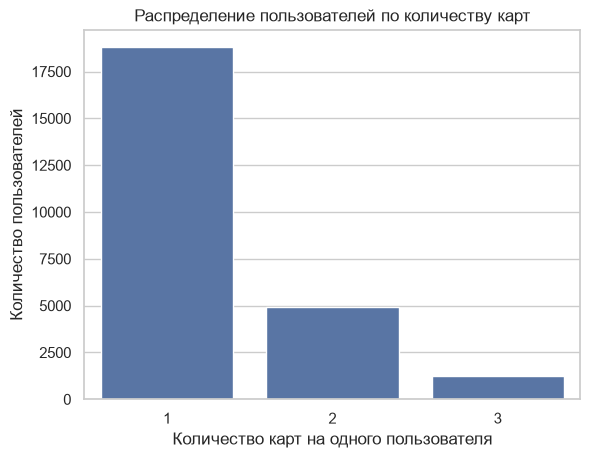

In [11]:
sns.barplot(
    x=cards_per_customer.index,
    y=cards_per_customer.values
)

plt.title("Распределение пользователей по количеству карт")
plt.xlabel("Количество карт на одного пользователя")
plt.ylabel("Количество пользователей")

plt.show()

In [12]:
user_1_cards = cards_per_customer.loc[1]
user_2_cards = cards_per_customer.loc[2]
user_3_cards = cards_per_customer.loc[3]

total_users = cards_per_customer.sum()

percentage_1_cards = user_1_cards/total_users * 100
percentage_2_cards = user_2_cards/total_users * 100
percentage_3_cards = user_3_cards/total_users * 100


print(f"Пользователей с 1 картой: {user_1_cards}")
print(f"Доля пользователей с 1 картой: {percentage_1_cards:.2f}%")
print(f"Пользователей с 2 картами: {user_2_cards}")
print(f"Доля пользователей с 2 картами: {percentage_2_cards:.2f}%")
print(f"Пользователей с 3 картами: {user_3_cards}")
print(f"Доля пользователей с 3 картами: {percentage_3_cards:.2f}%")


Пользователей с 1 картой: 18796
Доля пользователей с 1 картой: 75.18%
Пользователей с 2 картами: 4951
Доля пользователей с 2 картами: 19.80%
Пользователей с 3 картами: 1253
Доля пользователей с 3 картами: 5.01%


## Вывод по разделу: 

Около 25% пользователей владеют более чем одной картой. При этом около 5% пользователей имеют наибольшее количество — 3 карты. Данная группа может представлять интерес для дальнейшего анализа. Вопрос о статистической связи между количеством карт и вероятностью мошеннической активности может быть проверен в отдельном проекте, где представлены транзакции и признак мошенничества

## Исследование связи между **Credit_Limit** и **Card_Type**. 


In [13]:
avg_limit_per_card_type = df.groupby("Card_Type", as_index=False)["Credit_Limit"].mean()
print(avg_limit_per_card_type)

avg_limit_per_card_type["Credit_Limit_mln"] = (
    avg_limit_per_card_type["Credit_Limit"] / 1_000_000
)

  Card_Type  Credit_Limit
0   Classic      99709.13
1      Gold     500039.60
2  Platinum    1098240.90
3    Silver     224992.92


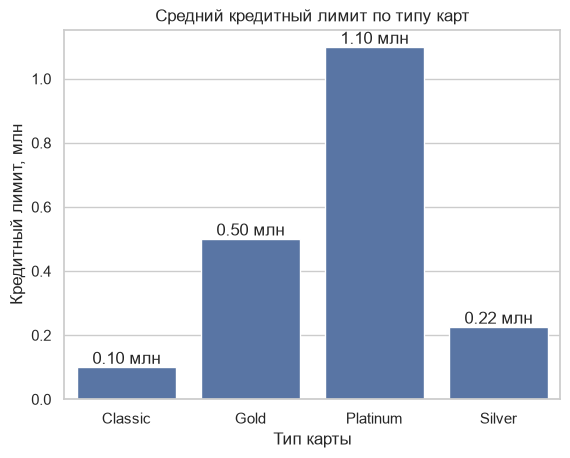

In [14]:
ax = sns.barplot(
    data=avg_limit_per_card_type,
    x="Card_Type",
    y="Credit_Limit_mln"
)

plt.xlabel("Тип карты")
plt.ylabel("Кредитный лимит, млн")
plt.title("Средний кредитный лимит по типу карт")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f млн")

plt.show()

Gold и Silver являются наиболее распространёнными типами карт, при этом их средние кредитные лимиты существенно ниже, чем у Platinum. Это позволяет предположить, что популярность типа карты не определяется исключительно величиной кредитного лимита.

Для проверки данной гипотезы необходимо сопоставить Card_Type с Credit_Limit и проверить наличие связи между типом карты и величиной кредитного лимита, сравнив медиану, среднее значение и диапазон кредитных лимитов для каждого типа карт.

Важным моментом при проверке гипотезы о выборе карт по кредитному лимиту является усреднённое значение по типу, в противном случае широкие диапазоны значений кредитного лимита не отвечают на вопрос о популярности типов карт

In [15]:
Q1 = df["Credit_Limit"].quantile(0.25)
Q3 = df["Credit_Limit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")

outliers = df[
    (df["Credit_Limit"] < lower_bound) |
    (df["Credit_Limit"] > upper_bound)
]

print(f"Количество выбросов: {len(outliers)}")
print(f"Доля выбросов: {len(outliers) / len(df) * 100:.2f}%")

print("\nНаименьшие значения среди выбросов:")
print(outliers["Credit_Limit"].sort_values().head())

print("\nНаибольшие значения среди выбросов:")
print(outliers["Credit_Limit"].sort_values(ascending=False).head())

Q1: 162030.00
Q3: 618074.00
IQR: 456044.00
Нижняя граница: -522036.00
Верхняя граница: 1302140.00
Количество выбросов: 1462
Доля выбросов: 4.50%

Наименьшие значения среди выбросов:
25950    1302222
27699    1302268
32204    1302278
5601     1302476
27729    1302551
Name: Credit_Limit, dtype: int64

Наибольшие значения среди выбросов:
12620    1499927
7256     1499718
15190    1499653
9769     1499574
16889    1499322
Name: Credit_Limit, dtype: int64


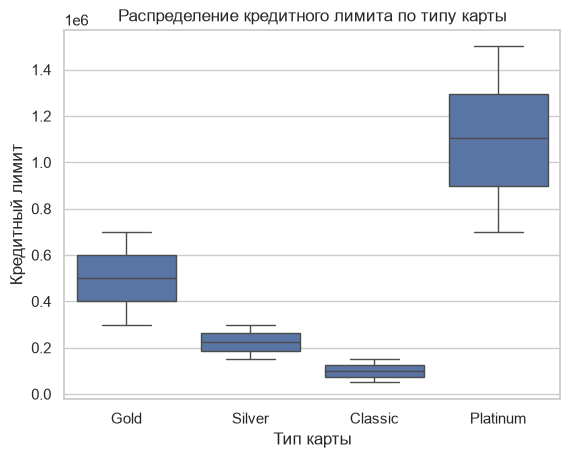

In [16]:
sns.boxplot(
    data=df,
    x="Card_Type",
    y="Credit_Limit"
)

plt.title("Распределение кредитного лимита по типу карты")
plt.xlabel("Тип карты")
plt.ylabel("Кредитный лимит")

plt.show()

## Вывод по разделу 

4,5% карт имеют статистически выделяющиеся значения кредитного лимита (>1,3 млн). При этом значения находятся в допустимом диапазоне датасета, поэтому оснований считать их ошибками нет

## Исследование связи между **Credit_Limit** и **Card_Network**

In [17]:
count_card_network = df["Card_Network"].value_counts()
print(count_card_network)

Card_Network
American Express    8276
RuPay               8141
Visa                8101
Mastercard          7939
Name: count, dtype: int64


In [18]:
count_card_network_per_type = df.groupby("Card_Type")["Card_Network"].value_counts().reset_index(name="Count")
print(count_card_network_per_type)

   Card_Type      Card_Network  Count
0    Classic             RuPay   1882
1    Classic  American Express   1879
2    Classic              Visa   1835
3    Classic        Mastercard   1752
4       Gold  American Express   2544
5       Gold             RuPay   2491
6       Gold              Visa   2472
7       Gold        Mastercard   2466
8   Platinum  American Express   1559
9   Platinum              Visa   1530
10  Platinum             RuPay   1518
11  Platinum        Mastercard   1475
12    Silver  American Express   2294
13    Silver              Visa   2264
14    Silver             RuPay   2250
15    Silver        Mastercard   2246


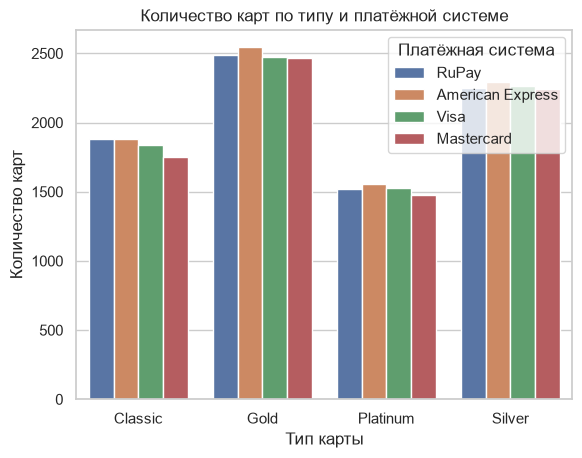

In [19]:
sns.barplot(
    data=count_card_network_per_type,
    x="Card_Type",
    y="Count",
    hue="Card_Network"
)
plt.title("Количество карт по типу и платёжной системе")
plt.xlabel("Тип карты")
plt.ylabel("Количество карт")
plt.legend(title="Платёжная система")
plt.show()

На диаграмме наблюдается относительно равномерное распределение карт между четырьмя платёжными системами внутри каждого типа карты. Ни одна из платёжных систем не демонстрирует устойчивого доминирования во всех категориях. При этом небольшие различия в количестве карт присутствуют: например, для Gold наибольшее количество приходится на American Express, тогда как для Classic и Silver различия между системами менее выражены. В целом внутри каждого типа карты платёжные системы представлены относительно равномерно; выраженной зависимости распределения типа карты от платёжной системы визуально не наблюдается

In [20]:
card_network_per_limit = df.groupby("Card_Network")["Credit_Limit"].mean()
print(card_network_per_limit)

Card_Network
American Express   446517.71
Mastercard         444327.42
RuPay              442321.34
Visa               445909.23
Name: Credit_Limit, dtype: float64


In [21]:
card_network_per_limit = (
    df.groupby(["Card_Type", "Card_Network"])["Credit_Limit"].mean()
)

print(card_network_per_limit)

Card_Type  Card_Network    
Classic    American Express     99601.19
           Mastercard          100983.58
           RuPay                99014.21
           Visa                 99315.58
Gold       American Express    502987.82
           Mastercard          498886.17
           RuPay               498116.94
           Visa                500093.56
Platinum   American Express   1099448.88
           Mastercard         1094719.55
           RuPay              1096792.63
           Visa               1101841.72
Silver     American Express    224319.16
           Mastercard          225123.57
           RuPay               226156.78
           Visa                224389.33
Name: Credit_Limit, dtype: float64


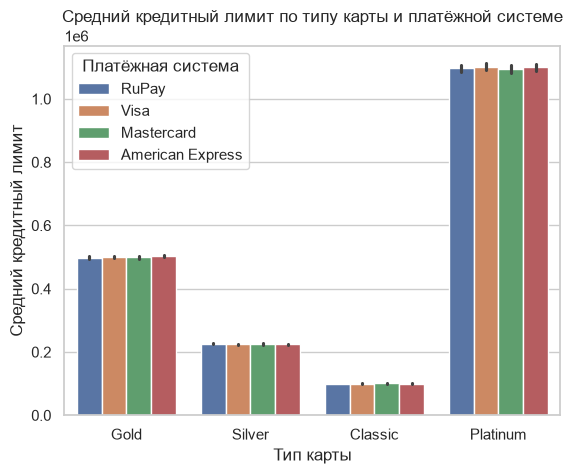

In [22]:
sns.barplot(
    data=df,
    x="Card_Type",
    y="Credit_Limit",
    hue="Card_Network",
    estimator="mean"
)

plt.title("Средний кредитный лимит по типу карты и платёжной системе")
plt.xlabel("Тип карты")
plt.ylabel("Средний кредитный лимит")
plt.legend(title="Платёжная система")

plt.show()

Судя по таблице и диаграмме, разница между средним кредитным лимитом внутри одного типа карты для разных платёжных систем невелика: лимиты распределены практически равномерно. Величина лимита определяется в первую очередь типом карты, а не платёжной системой

## Карты по статусу

In [23]:
status_counts = df["Card_Status"].value_counts()
status_share = df["Card_Status"].value_counts(normalize=True) * 100

print(status_counts)
print("\nДоля, %:")
print(status_share.round(2))

Card_Status
Active     30463
Expired     1007
Blocked      646
Lost         341
Name: count, dtype: int64

Доля, %:
Card_Status
Active    93.86
Expired    3.10
Blocked    1.99
Lost       1.05
Name: proportion, dtype: float64


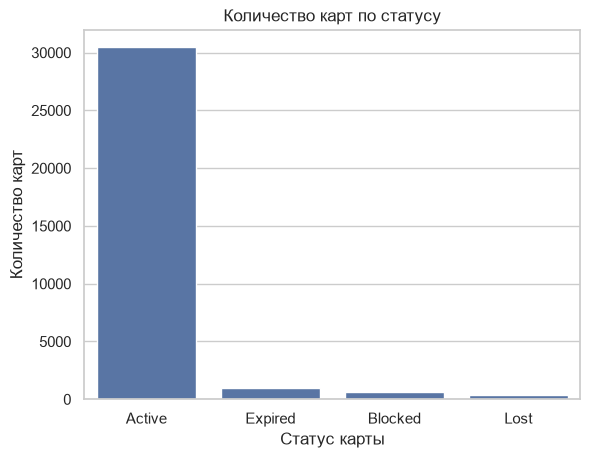

In [24]:
sns.countplot(
    data=df,
    x="Card_Status"
)

plt.title("Количество карт по статусу")
plt.xlabel("Статус карты")
plt.ylabel("Количество карт")

plt.show()

## Вывод по разделу

Подавляющее большинство карт (около **94%**) являются **активными**. Остальные карты распределены между статусами Expired (**3,1%**), Blocked (**2,0%**) и Lost (**1,1%**). Доля проблемных карт невелика, однако их стоит учитывать при сопоставлении с транзакциями в дальнейшем анализе.

## Карты по поддержке бесконтактной оплаты

In [25]:
contactless_counts = df["Contactless"].value_counts()
contactless_share = df["Contactless"].value_counts(normalize=True) * 100

print(contactless_counts)
print("\nДоля, %:")
print(contactless_share.round(2))

Contactless
Yes    27632
No      4825
Name: count, dtype: int64

Доля, %:
Contactless
Yes   85.13
No    14.87
Name: proportion, dtype: float64


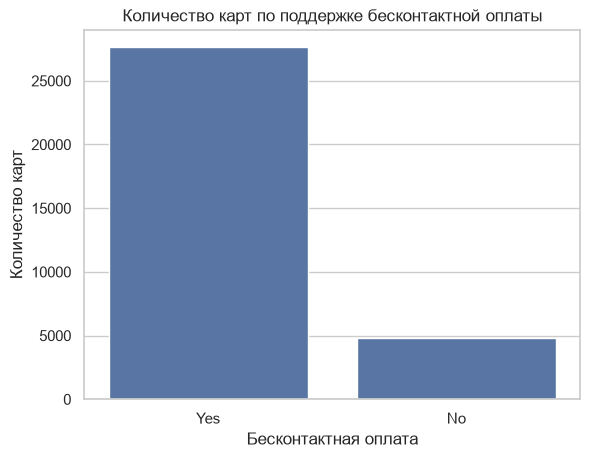

In [26]:
sns.countplot(
    data=df,
    x="Contactless"
)

plt.title("Количество карт по поддержке бесконтактной оплаты")
plt.xlabel("Бесконтактная оплата")
plt.ylabel("Количество карт")

plt.show()

## Вывод по разделу

Подавляющее большинство карт (около **85%**) поддерживают **бесконтактную оплату**. Карты без такой поддержки представлены значительно реже (~15%). Признак имеет слабую вариативность и, вероятно, не будет информативным при дальнейшем анализе.

## Карты по способу эмиссии

In [27]:
mode_counts = df["Card_Mode"].value_counts()
mode_share = df["Card_Mode"].value_counts(normalize=True) * 100

print(mode_counts)
print("\nДоля, %:")
print(mode_share.round(2))

Card_Mode
Physical    26008
Virtual      6449
Name: count, dtype: int64

Доля, %:
Card_Mode
Physical   80.13
Virtual    19.87
Name: proportion, dtype: float64


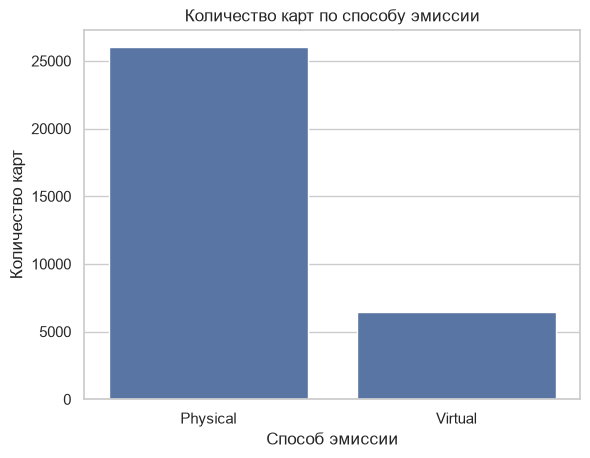

In [28]:
sns.countplot(
    data=df,
    x="Card_Mode"
)

plt.title("Количество карт по способу эмиссии")
plt.xlabel("Способ эмиссии")
plt.ylabel("Количество карт")

plt.show()

## Вывод по разделу

Среди карт в датасете преобладают **физические карты** — их доля составляет **80%**. Виртуальные карты представлены в четыре раза реже (~20%). В дальнейшем это распределение может представлять интерес при сопоставлении со способом оплаты в транзакциях.

## Срок действия карт

In [29]:
df["Issue_Date"] = pd.to_datetime(df["Issue_Date"])
df["Expiry_Date"] = pd.to_datetime(df["Expiry_Date"])

df["Card_Lifetime_Days"] = (df["Expiry_Date"] - df["Issue_Date"]).dt.days
df["Card_Lifetime_Years"] = df["Card_Lifetime_Days"] / 365.25

print(df[["Card_Type", "Issue_Date", "Expiry_Date", "Card_Lifetime_Years"]].head(10))
print("\n-----------------------")
print("Статистика срока действия карт (в годах):")
print(df["Card_Lifetime_Years"].describe())

  Card_Type Issue_Date Expiry_Date  Card_Lifetime_Years
0      Gold 2021-04-24  2026-04-24                 5.00
1    Silver 2020-06-30  2025-06-30                 5.00
2      Gold 2022-04-04  2027-04-04                 5.00
3    Silver 2020-07-21  2025-07-21                 5.00
4      Gold 2024-07-24  2029-07-24                 5.00
5   Classic 2019-10-08  2024-10-08                 5.00
6    Silver 2019-05-27  2024-05-27                 5.00
7  Platinum 2022-05-23  2027-05-23                 5.00
8      Gold 2022-01-06  2027-01-06                 5.00
9  Platinum 2026-07-17  2031-07-17                 5.00

-----------------------
Статистика срока действия карт (в годах):
count   32457.00
mean        5.00
std         0.00
min         5.00
25%         5.00
50%         5.00
75%         5.00
max         5.00
Name: Card_Lifetime_Years, dtype: float64


In [30]:
print("Распределение срока действия карт (в днях):")
print(df["Card_Lifetime_Days"].value_counts().sort_index())
print(f"\nСредний срок: {df['Card_Lifetime_Years'].mean():.2f} года")

Распределение срока действия карт (в днях):
Card_Lifetime_Days
1826    24433
1827     8024
Name: count, dtype: int64

Средний срок: 5.00 года


## Вывод по разделу 

Все карты в датасете выпускаются на один и тот же срок — **5 лет**. Единственное отличие (1826 против 1827 дней) обусловлено високосными годами и носит чисто технический характер, поэтому этот признак не имеет содержательной вариативности и **не представляет интереса для дальнейшего анализа**

## Общие выводы

Проведённый разведочный анализ датасета о банковских картах позволил сформулировать следующие ключевые выводы:

1. **Структура данных.** Датасет содержит **32 457 карт** и **25 000 уникальных клиентов** по **10 признакам**. Пропущенные значения и полные дубликаты отсутствуют.

2. **Платёжные системы.** Четыре платёжные системы (American Express, RuPay, Visa, Mastercard) представлены практически равномерно (по ~25%). Выраженного доминирования нет.

3. **Типы карт.** Наиболее популярны **Gold (~31%)** и **Silver (~28%)**, далее Classic (~23%) и Platinum (~19%).

4. **Карты на одного клиента.** Около **25% клиентов** владеют более чем одной картой, ~5% — тремя.

5. **Кредитный лимит.** Средний лимит растёт по мере повышения класса карты: Classic (~0,10 млн) → Silver (~0,22 млн) → Gold (~0,50 млн) → Platinum (~1,10 млн). ~4,5% карт имеют статистически выделяющиеся значения лимита (>1,3 млн), но они остаются в допустимом диапазоне.

6. **Платёжная система и лимит.** Внутри одного типа карты средний лимит одинаков для всех платёжных систем — платёжная система практически не влияет на величину лимита.

7. **Статус, контактность и способ эмиссии карты.** Большинство карт активны, преобладают карты с поддержкой бесконтактной оплаты, физические карты выпускаются чаще, чем виртуальные.

8. **Срок действия.** Все карты выпускаются на один и тот же срок — **5 лет** (разница в 1 день обусловлена лишь високосными годами). Признак не имеет содержательной вариативности и не представляет интереса для дальнейшего анализа.

Полученные закономерности могут быть использованы при дальнейшем анализе для **выявления мошеннических операций** — в частности, количество карт на клиента и прочие характеристики карт могут быть сопоставлены с транзакциями и признаком мошенничества в рамках отдельного проекта.